## Property Prices in Boston -1970



Welcome to Boston Massachusetts in the 1970s! Imagine you're working for a real estate development company. Your company wants to value any residential project before they start. You are tasked with building a model that can provide a price estimate based on a home's characteristics like:
* The number of rooms
* The distance to employment centres
* How rich or poor the area is
* How many students there are per teacher in local schools etc

<img src=https://i.imgur.com/WfUSSP7.png height=350>

To accomplish your task you will:

1. Analyse and explore the Boston house price data
2. Split your data for training and testing
3. Run a Multivariable Regression
4. Evaluate how your model's coefficients and residuals
5. Use data transformation to improve your model performance
6. Use your model to estimate a property price

### Import Statements


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

### Presentation



In [4]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the dataset

In [13]:
df = pd.read_csv("boston.csv", index_col=0)     ## Index column is the same as the index
df.sample(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
78,0.06,0.00,12.83,0.00,0.44,6.23,53.70,5.01,5.00,398.00,18.70,386.40,12.34,21.20
478,10.23,0.00,18.10,0.00,0.61,6.18,96.70,2.17,24.00,666.00,20.20,379.70,18.03,14.60
329,0.07,0.00,3.24,0.00,0.46,6.33,17.20,5.21,4.00,430.00,16.90,375.21,7.34,22.60
236,0.52,0.00,6.20,1.00,0.51,6.63,76.50,4.15,8.00,307.00,17.40,388.45,9.54,25.10
199,0.03,95.00,1.47,0.00,0.40,6.97,15.30,7.65,3.00,402.00,17.00,396.90,4.56,34.90


### Initial checks

In [18]:
#### Checks 1 ( head, tail,, shape, data types, column names)
df.head()
df.tail()
df.shape            #(506 by 14)
df.columns          # all as codes
df.dtypes           # All data as floats

## No adjustments needed so far

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
PRICE      float64
dtype: object

In [21]:
#### Checks 2 missing values, column removals and duplicates

    #### Missing values
df.isna().sum()                                         # No  missing values

    #### Remove columns
                                                        #  no need to remove columns

    #### Checks for duplicates
df.duplicated(keep=False).value_counts()                # No duplicates since all are false


False    506
Name: count, dtype: int64

### Descriptive statistics

In [22]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.39,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.23,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


### Visualise the Data

**Challenge**: Having looked at some descriptive statistics, visualise the data for your model. Use [Seaborn's `.displot()`](https://seaborn.pydata.org/generated/seaborn.displot.html#seaborn.displot) to create a bar chart and superimpose the Kernel Density Estimate (KDE) for the following variables:
* PRICE: The home price in thousands.
* RM: the average number of rooms per owner unit.
* DIS: the weighted distance to the 5 Boston employment centres i.e., the estimated length of the commute.
* RAD: the index of accessibility to highways.

Try setting the `aspect` parameter to `2` for a better picture.

What do you notice in the distributions of the data?

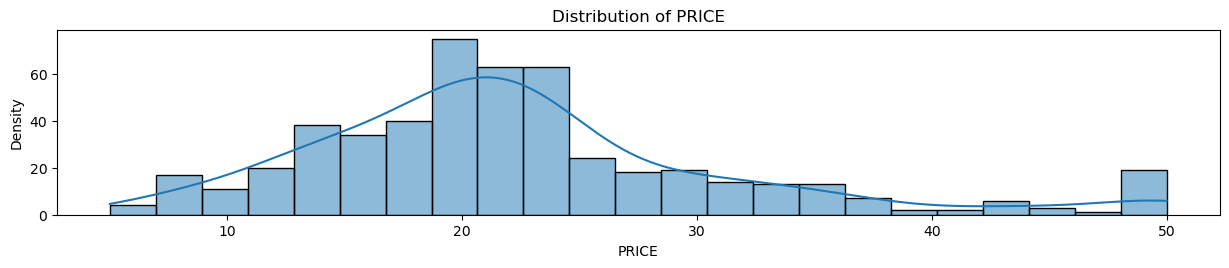

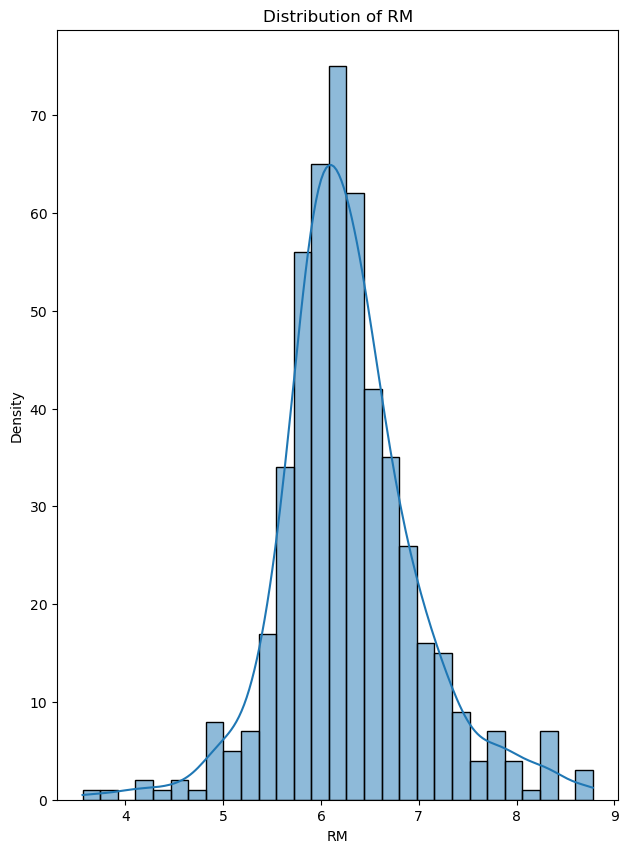

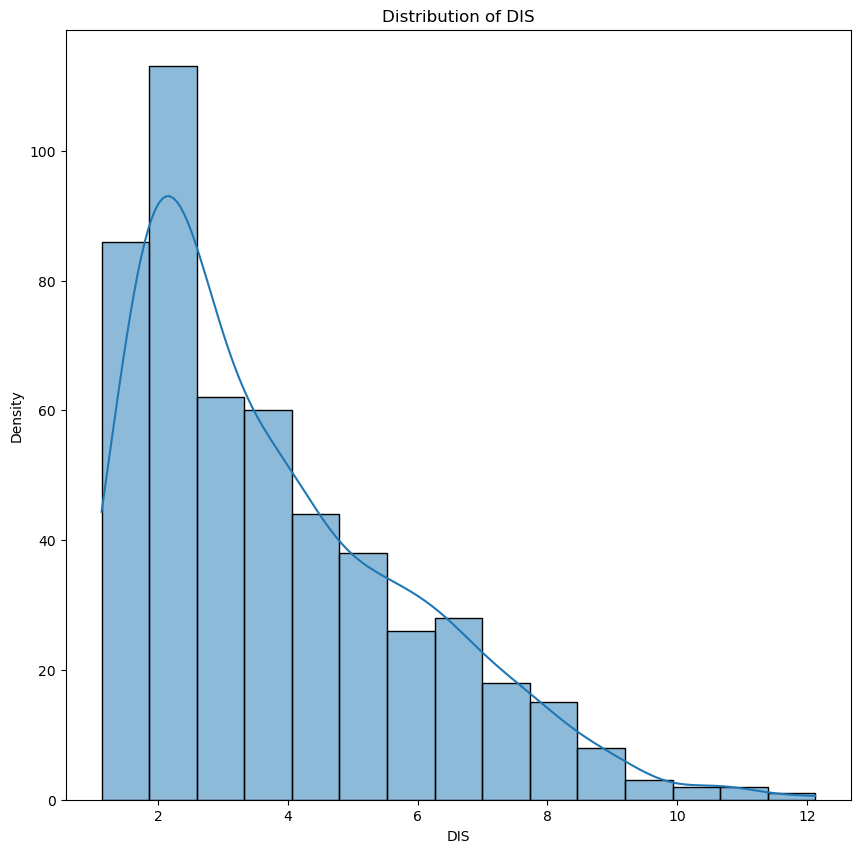

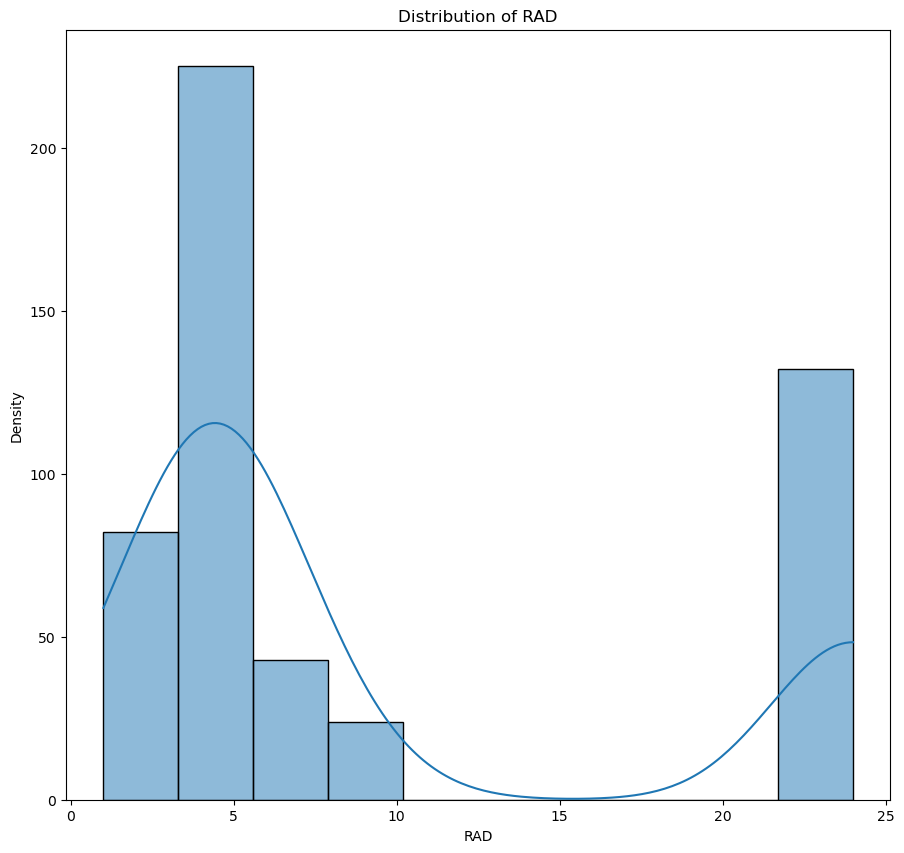

In [44]:
df1 = df[["PRICE","RM", "DIS", "RAD"]]

for column in df1:
    # features
    plt.figure(figsize = (15,10))

    #function
    ax = sns.histplot(data = df1, x= column, kde=True)

    # Extra arguments
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.title(f"Distribution of {column}")
    ax.set_aspect(aspect  = 0.1, adjustable = "box")            # How to stretch the axis

    plt.show()
